# Graph API

In [17]:
from dotenv import load_dotenv
load_dotenv()

import os

In [18]:
hf_token=os.getenv("HF_TOKEN")

In [24]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from IPython.display import Image, display


In [20]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

In [36]:
from langchain_core.messages import SystemMessage, HumanMessage

In [21]:
from typing import Annotated, List
import operator
from pydantic import BaseModel,Field


#schema for structured output to use in planning

class Section(BaseModel):
    name:str=Field(description="Name for this section of report")
    description:str=Field(description="Brief overview of the main topics and concepts to be covered")

In [22]:
class Sections(BaseModel):
    sections:List[Section]=Field(description="Sections of the report")

#augment the LLM with the schema for structured output

planner=llm.with_structured_output(Sections)

In [26]:
from langgraph.types import Send

#graph state

class State(TypedDict):
    topic:str #report topic
    sections:list[Section] #list of report sections
    completed_sections:Annotated[list,operator.add] #all workrs to this key in parallel
    final_report:str #final report

#worker state

class WorkerState(TypedDict):
    section:Sections
    completed_sections:Annotated[list,operator.add]

#nodes

#Take a topic → ask an LLM to create a structured plan → return sections for downstream workers.
def orchestrator(state:State):
    """Orchestrator that generates a plan for the report"""

    #generate queries
    report_sections=planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report. "),
            HumanMessage(content=f"Here is the report topic : {state['topic']}")
        ]
    )

    return {"sections":report_sections.sections}


# Take one section (name + description) → ask LLM to write it → return final markdown content
def llm_call(state:WorkerState):
    """Worker writes a section of report"""
    #generate section
    section=llm.invoke(
        [
            SystemMessage(content="Write a report section following the provided name and description. Include no preamble for each section. Use markdown formatting"),
            HumanMessage(content=f"here is the section name {state['section'].name} and description : {state['section'].description}")
        ]
    )

    #write the updated section to completed sections
    return {"completed_sections":[section.content]}
    

In [27]:
def synthesizer(state:State):
    """Synthesise full report from sections"""
    #list of completed sections

    completed_sections=state['completed_sections']

    #format completed section to str to use as context for final sections
    completed_report_sections="\n\n---\n\n".join(completed_sections)

    return {"final_report":completed_report_sections}

In [31]:
#conditional Edge function to create llm_call workers that each write a section of the report

def assign_workers(state:State):
    """Assign a worker to each section in the plan"""

    #kick off section writing in parallel via Send() API

    return [Send("llm_call",{"section":s}) for s in state['sections']]

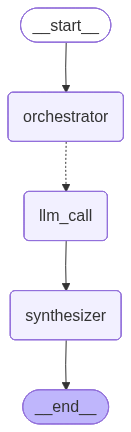

In [33]:
#build workflow

orchestrator_worker_builder=StateGraph(State)

#add the nodes
orchestrator_worker_builder.add_node("orchestrator",orchestrator)
orchestrator_worker_builder.add_node("llm_call",llm_call)
orchestrator_worker_builder.add_node("synthesizer",synthesizer)

#add edges to connect nodes

orchestrator_worker_builder.add_edge(START,"orchestrator")
orchestrator_worker_builder.add_conditional_edges("orchestrator",assign_workers,['llm_call'])
orchestrator_worker_builder.add_edge('llm_call','synthesizer')
orchestrator_worker_builder.add_edge('synthesizer',END)

#compile the workflow

orchestrator_worker=orchestrator_worker_builder.compile()

#show the workflow

display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

In [37]:
#invoke

state=orchestrator_worker.invoke({"topic":"Create a report on LLM scaling laws"})

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 5, model: gemini-2.5-flash\nPlease retry in 16.792942521s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerMinutePerProjectPerModel-Fre

from Ipython.display import Markdown
Markdown(state['final_report'])

In [38]:
from langchain_huggingface import ChatHuggingFace,HuggingFaceEndpoint

llm=HuggingFaceEndpoint(
    repo_id="Qwen/Qwen2.5-7B-Instruct",
    task="conversational",
    huggingfacehub_api_token=hf_token,
    max_new_tokens=200,
    temperature=0.7
)

llm = ChatHuggingFace(llm=llm)

In [40]:
from typing import Annotated, List, TypedDict
from pydantic import BaseModel, Field
import operator
import json
import re

from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langchain_core.messages import SystemMessage, HumanMessage


# -----------------------------
# Pydantic Schema (for structure only)
# -----------------------------

class Section(BaseModel):
    name: str
    description: str


class Sections(BaseModel):
    sections: List[Section]


# -----------------------------
# Graph State
# -----------------------------

class State(TypedDict):
    topic: str
    sections: list[Section]

    completed_sections: Annotated[list, operator.add]
    final_report: str


class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]


# -----------------------------
# Robust JSON extractor (IMPORTANT)
# -----------------------------

def extract_json(text: str):
    """
    Safe JSON extraction for Hugging Face models
    """

    # remove markdown fences if present
    text = text.replace("```json", "").replace("```", "")

    # find JSON object
    match = re.search(r"\{.*\}", text, re.DOTALL)
    if not match:
        raise ValueError(f"No JSON found in output:\n{text}")

    raw = match.group()

    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        # extra cleanup attempt
        raw = raw.replace("\n", " ")
        return json.loads(raw)


# -----------------------------
# ORCHESTRATOR NODE
# -----------------------------

def orchestrator(state: State):
    """Generate plan using HF model"""

    response = llm.invoke(
        [
            SystemMessage(content="""
You are a planning agent.

Return ONLY valid JSON.

No explanation.
No markdown.
No backticks.

Format:
{
  "sections": [
    {
      "name": "section name",
      "description": "section description"
    }
  ]
}
"""),
            HumanMessage(content=f"Topic: {state['topic']}")
        ]
    )

    data = extract_json(response.content)

    sections = [
        Section(**s) for s in data["sections"]
    ]

    return {"sections": sections}


# -----------------------------
# WORKER NODE
# -----------------------------

def llm_call(state: WorkerState):
    """Write one section"""

    response = llm.invoke(
        [
            SystemMessage(content="""
Write a detailed report section in markdown.

Rules:
- No introduction
- No preamble
- Only section content
"""),
            HumanMessage(content=f"""
Section Name: {state['section'].name}
Description: {state['section'].description}
""")
        ]
    )

    return {
        "completed_sections": [response.content]
    }


# -----------------------------
# SYNTHESIZER
# -----------------------------

def synthesizer(state: State):
    """Combine all sections"""

    return {
        "final_report": "\n\n---\n\n".join(
            state["completed_sections"]
        )
    }


# -----------------------------
# WORKER ASSIGNMENT (Send API)
# -----------------------------

def assign_workers(state: State):
    """Spawn workers dynamically"""

    return [
        Send("llm_call", {"section": s})
        for s in state["sections"]
    ]


# -----------------------------
# BUILD GRAPH
# -----------------------------

builder = StateGraph(State)

builder.add_node("orchestrator", orchestrator)
builder.add_node("llm_call", llm_call)
builder.add_node("synthesizer", synthesizer)

builder.add_edge(START, "orchestrator")

builder.add_conditional_edges(
    "orchestrator",
    assign_workers,
    ["llm_call"]
)

builder.add_edge("llm_call", "synthesizer")
builder.add_edge("synthesizer", END)

graph = builder.compile()


# -----------------------------
# RUN
# -----------------------------

result = graph.invoke(
    {"topic": "Create a report on LLM scaling laws"}
)

print(result["final_report"])

# Introduction

Language models (LLMs) have seen an unprecedented growth in their scale, representation capacity, and performance over the past few years. This scaling has been driven by several factors, including advancements in hardware technologies, improvements in training methodologies, and the availability of large datasets. The scaling laws in LLMs refer to the relationships between the model's size, training data, compute resources, and performance metrics such as perplexity and accuracy. Understanding these laws is crucial for several reasons:

1. **Resource Allocation**: Knowing the scaling laws helps in efficiently allocating computational resources. It enables researchers and practitioners to estimate the resources needed for training larger models, which is essential for both academic and industrial settings.

2. **Performance Prediction**: Scaling laws provide a framework for predicting the performance of LLMs at different scales. This is particularly useful for setting r